<a href="https://colab.research.google.com/github/Mariano-ds/centollas2026/blob/main/francisco/francisco_tp2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Diplomatura en Ciencia de Datos, Aprendizaje Automático y sus Aplicaciones**

## **Edición 2026**

### Parte 2: Análisis exploratorio y curación de datos

---
## Mentoría 15: *¿Cuándo y dónde pescar Centollas en el Canal Beagle?*

**Entrega individual:** Francisco Capobianco

**Objetivo**: responder al menos tres de las preguntas planteadas por el grupo en el trabajo práctico 1.

Se espera un manejo más avanzado del set de datos, en donde el grupo de trabajo relacione las distintas columnas del dataset (variables) para responder preguntas con una complejidad mayor que la de realizar una mera descripción.

Cada respuesta a cada pregunta contiene: (1) el planteo de la pregunta y sus implicancias, (2) el desarrollo paso a paso, y (3) al menos un gráfico con su interpretación.

## Preguntas planteadas en el TP1 (grupal)

En `mariano_tp1.ipynb` el grupo (Baggini, Navarro, Capobianco) planteó estas 5 preguntas para responder en el TP2:

1. ¿Cuál fue la evolución temporal en la pesca de **cada especie**?
2. ¿Cuándo se encontraron más huevos en las hembras?
3. ¿Dónde se pescaron mayor cantidad de hembras con huevos en estos períodos?
4. ¿Cuáles son los puntos de mayor cantidad de pesca?
5. ¿Dónde y cuándo se recomienda no pescar?

Para esta entrega individual respondo en profundidad las preguntas **1, 2 y 3** (cumpliendo el mínimo de tres pedido por la consigna), y cierro con una síntesis breve que retoma la pregunta 5 combinando los tres resultados anteriores.

## Nota metodológica: revisión de `mariano/mariano_tp2.ipynb`

Antes de escribir esta entrega revisé la resolución de Mariano para el mismo TP2, buscando qué podía corregir o sumar en mi propia versión. Encontré varios puntos concretos, verificados corriendo el pipeline paso a paso contra los datos reales (no son solo lectura de código):

1. **Bug real en el mapeo de estado de huevos.** Su diccionario clasifica los códigos `6` ("embriogénesis heterogénea") y `7` ("poca cantidad de huevos") como *"Sin huevos"*, pero el diccionario de datos del proyecto dice explícitamente que ambos códigos **sí** implican presencia de huevos. Esto subestima justo la variable central de las preguntas 2 y 3. Más abajo cuantifico el impacto real en los datos (cambia hasta ~12 puntos porcentuales según la campaña).
2. **Diccionario de correcciones incompleto y fragil.** Revisando los valores únicos de `huevos` aparecen 8 variantes de texto libre para el código 7 (`"7 en 1"`, `"7 clutch incompleto"`, `"7, pocos <20"`, `"7, 4 huevos degenerados"`, etc.). El TP2 original solo contempla una (`"7 en 1"`) y la mapea, además, al código equivocado (1 en lugar de 7). Las otras 7 variantes no rompen su notebook por pura casualidad: todas esas filas tienen `localizacion`, `latitud` y `longitud` nulas a la vez, y un filtro geográfico posterior (sin relación con `huevos`) las elimina antes de llegar a la celda de corrección. Lo mismo pasa con el valor `'3p'` de `cirripedio`, que falta en su diccionario. Acá reemplazo el diccionario cerrado por una regla robusta (tomar el primer número de la cadena) que cubre todas las variantes por diseño.
3. **Filtro de especie no explicitado.** El TP2 original se queda solo con `especie == 2` (*Paralomis granulosa*, "centollón") desde la celda de limpieza y nunca vuelve a mencionar la decisión, a pesar de que la propia pregunta 1 del TP1 pide la evolución "de cada especie". *Lithodes santolla* (la "centolla" que da nombre al proyecto) queda con apenas 313 registros crudos frente a los 10.737 de *Paralomis granulosa*: es una decisión razonable, pero hay que decirla. Acá la explicito y, para la pregunta 1, muestro ambas especies.
4. **Un único pipeline lineal descarta filas que otras preguntas sí podrían usar.** El TP2 original exige `latitud`, `longitud` y `localizacion` no nulos simultáneamente antes de cualquier análisis, aunque preguntas puramente temporales (como la 2) no necesitan geolocalización. Acá separo la limpieza de base de los filtros específicos de cada pregunta, y eso recupera filas utilizables (por ejemplo, ~108 registros con coordenadas válidas pero sin el nombre de la localización).
5. **Inconsistencia menor en `localizacion`** (`"WP 59"` vs `"wp 60"`, un espacio inicial en `" frente bal. Ponsatti"`). Verifiqué que en este dataset puntual no llega a fusionar grupos por casualidad (los waypoints en mayúscula no tienen par en minúscula), pero normalizar (`strip` + `lower`) es una buena práctica preventiva que aplico de todos modos.
6. **Un TODO propio sin resolver:** el texto de la celda de `estado_caparazon` dice que la columna "es flotante en lugar de entero" pero nunca la convierte. Acá se corrige.
7. El TP2 original queda con una **celda final vacía** y un TO-DO de 4 puntos sin resolver (mapa de lat/lon, imputación de profundidad, EDA de caparazón, gráfico de esfuerzo de pesca). Cierro los cuatro puntos al final de este notebook.

Estas correcciones se aplican en las celdas de limpieza que siguen, y su impacto se muestra explícitamente en la Pregunta 2.

## 0. Carga y limpieza base

In [1]:
# Librerias utilizadas
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.neighbors import NearestNeighbors

sns.set_context('talk')
pd.options.display.max_rows = 200
pd.options.display.max_colwidth = 400

In [2]:
# Carga de datos -- CORRECCION #1: ambos archivos se leen desde el propio
# repo del equipo (en el TP2 original, 'centollas_mentoria.csv' se leia desde
# un repo externo del mentor mientras que 'jul97.csv' se leia desde este
# mismo repo; eso es inconsistente para reproducibilidad y mezcla encodings).
url_original = "https://raw.githubusercontent.com/Mariano-ds/centollas2026/main/datos/centollas_mentoria.csv"
url_jul97 = "https://raw.githubusercontent.com/Mariano-ds/centollas2026/main/datos/jul97.csv"

data_original = pd.read_csv(url_original, sep=';', engine='python', encoding='latin1')
data_jul97 = pd.read_csv(url_jul97, sep=';', engine='python', encoding='utf-8-sig')

data_original.columns = data_original.columns.str.strip().str.lower()
data_jul97.columns = data_jul97.columns.str.strip().str.lower()

df_raw = pd.concat([data_original, data_jul97], axis=0, ignore_index=True)
print(f"Filas totales: {df_raw.shape[0]} | Columnas totales: {df_raw.shape[1]}")
df_raw.head(2)

Filas totales: 13114 | Columnas totales: 20


,fecha,rk,tipo,localizacion,latitud,longitud,profundidad,especie,sexo,estado_caparazon,cirripedio,largo_caparazon,ancho_caparazon,largo_quela,ancho_quela,huevos,parasito,observaciones,unnamed: 18,unnamed: 19
0,ene_96,1,Captura total de 3 trampas,frente bal. Ponsatti,NaN,NaN,23.0,2,1,4.0,3,87.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ene_96,2,Captura total de 3 trampas,frente bal. Ponsatti,NaN,NaN,23.0,2,2,3.0,2,77.1,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN


In [3]:
# Columnas basura por separadores de mas, y limpieza minima (igual criterio que el TP2 original)
unnamed_cols = [c for c in df_raw.columns if c.startswith('unnamed')]
df_raw = df_raw.drop(columns=unnamed_cols)

n0 = len(df_raw)
df_raw = df_raw.dropna(subset=['estado_caparazon', 'largo_caparazon'], how='any').copy()
print(f"Se descartan {n0 - len(df_raw)} filas sin estado_caparazon o largo_caparazon -> quedan {len(df_raw):,} filas, {df_raw.shape[1]} columnas")

Se descartan 31 filas sin estado_caparazon o largo_caparazon -> quedan 13,083 filas, 18 columnas


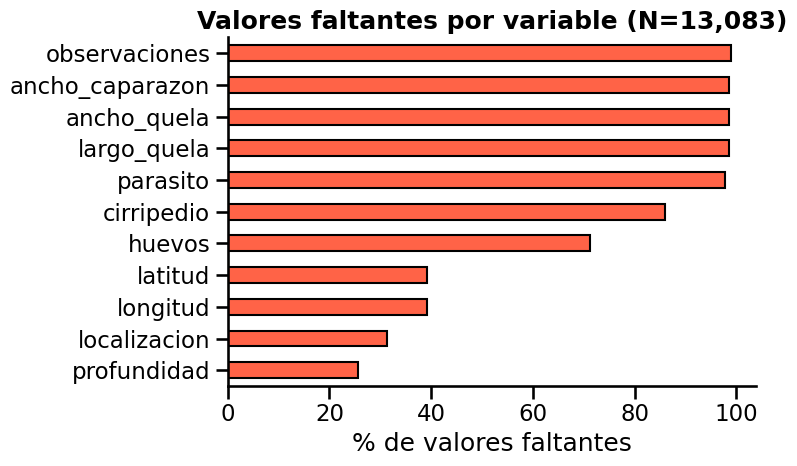

observaciones      98.91
ancho_caparazon    98.62
largo_quela        98.51
ancho_quela        98.51
parasito           97.75
cirripedio         85.94
huevos             71.29
longitud           39.27
latitud            39.27
localizacion       31.26
profundidad        25.58
dtype: float64

In [4]:
# Valores faltantes por variable (igual analisis que el TP2 original, sin la
# dependencia de 'missingno' para simplificar el entorno de ejecucion)
faltantes = df_raw.isnull().mean().sort_values(ascending=False) * 100
faltantes = faltantes[faltantes > 0].round(2)

fig, ax = plt.subplots(figsize=(8, 5))
faltantes.sort_values().plot(kind='barh', ax=ax, color='tomato', edgecolor='black')
ax.set_xlabel('% de valores faltantes')
ax.set_title(f'Valores faltantes por variable (N={len(df_raw):,})', fontweight='bold')
sns.despine()
plt.tight_layout()
plt.show()
faltantes

**CORRECCIÓN #2 — normalización de `localizacion`.** El texto libre de esta columna tiene inconsistencias de mayúsculas/espacios (`"WP 59"` vs `"wp 60"`, `" frente bal. Ponsatti"` con espacio inicial). Verifico cuánto cambia el conteo de valores únicos al normalizar antes de usar esta columna para agrupar.

In [5]:
def normalizar_localizacion(s):
    if pd.isna(s):
        return np.nan
    return re.sub(r'\s+', ' ', str(s).strip().lower())

df_raw['localizacion_norm'] = df_raw['localizacion'].apply(normalizar_localizacion)

n_orig = df_raw['localizacion'].nunique(dropna=True)
n_norm = df_raw['localizacion_norm'].nunique(dropna=True)
print(f"Localizaciones unicas -> original: {n_orig} | normalizada: {n_norm}")
print("(en este dataset puntual no hay colisiones reales por casualidad de que los "
      "waypoints en mayuscula no tienen par en minuscula, pero conviene normalizar "
      "como practica preventiva antes de cualquier agrupamiento por localizacion)")

Localizaciones unicas -> original: 62 | normalizada: 62
(en este dataset puntual no hay colisiones reales por casualidad de que los waypoints en mayuscula no tienen par en minuscula, pero conviene normalizar como practica preventiva antes de cualquier agrupamiento por localizacion)


**Clasificación del tipo de muestreo.** Según el diccionario de datos del proyecto, `desembarque` es una muestra sesgada a un tamaño determinado (el pescador elige qué desembarca), mientras que `cubierta` no está seleccionada por el pescador. Se agrega esta clasificación explícita (el TP2 original solo distinguía "trampa"/"línea" para el cálculo de esfuerzo, pero descartaba la columna `tipo` sin dejar registro de si el resto del dataset final mezclaba muestreo sesgado y no sesgado).

In [6]:
def extraer_num_trampas(tipo_str):
    # Extrae el numero de trampas equivalentes desde 'tipo' (1 linea = 10 trampas).
    if pd.isna(tipo_str):
        return np.nan
    texto = str(tipo_str).lower()
    match = re.search(r'(\d+\.?\d*)', texto)
    if not match:
        return np.nan
    numero = float(match.group(1))
    if 'trampa' in texto:
        return numero
    elif 'linea' in texto or 'línea' in texto:
        return numero * 10
    return np.nan

def clasificar_tipo(t):
    if pd.isna(t):
        return 'desconocido'
    s = str(t).lower()
    if 'desembarque' in s:
        return 'desembarque'          # sesgado a un tamano determinado
    if 'cubierta' in s:
        return 'cubierta'             # no sesgado
    if 'solo machos' in s:
        return 'trampa_solo_machos'   # esfuerzo con trampas, protocolo que solo reporta machos
    if 'trampa' in s or 'linea' in s or 'línea' in s:
        return 'trampa'
    return 'otro'

df_raw['num_trampas'] = df_raw['tipo'].apply(extraer_num_trampas)
df_raw['tipo_clase'] = df_raw['tipo'].apply(clasificar_tipo)
df_raw['tipo_clase'].value_counts()

tipo_clase
trampa                9407
desembarque           2587
cubierta               730
trampa_solo_machos     271
otro                    88
Name: count, dtype: int64

**Imputación de coordenadas.** Igual criterio que el TP2 original (mediana de latitud/longitud por localización), pero agrupando por `localizacion_norm`.

In [7]:
df_raw['coord_imputada'] = df_raw['latitud'].isna() | df_raw['longitud'].isna()
df_raw['latitud'] = df_raw['latitud'].fillna(df_raw.groupby('localizacion_norm')['latitud'].transform('median'))
df_raw['longitud'] = df_raw['longitud'].fillna(df_raw.groupby('localizacion_norm')['longitud'].transform('median'))

recuperadas = (df_raw['coord_imputada'] & df_raw['latitud'].notna()).sum()
sin_recuperar = df_raw['latitud'].isna().sum()
print(f"Coordenadas recuperadas por mediana de grupo: {recuperadas}")
print(f"Registros que siguen sin coordenadas (sin ninguna referencia previa en su localizacion): {sin_recuperar}")

Coordenadas recuperadas por mediana de grupo: 25
Registros que siguen sin coordenadas (sin ninguna referencia previa en su localizacion): 5113


**CORRECCIÓN #3 — limpieza de `huevos`, `parasito` y `cirripedio`.**

Reviso los valores únicos reales de `huevos` (no solo el `value_counts` de los más frecuentes) y encuentro 8 variantes de texto libre para el código 7 que el diccionario del TP2 original no cubre en su totalidad, además de un caso mapeado al código equivocado. En vez de seguir enumerando casos a mano, uso una regla general: tomar el primer número de la cadena como código real, y corregir el cero de más en 30/40 (en `huevos` el diccionario de datos solo define 0-7, a diferencia de `estado_caparazon` y `parasito`, donde "30" sí es un código legítimo).

In [8]:
huevos_unicos = df_raw['huevos'].dropna().unique()
variantes_texto_7 = sorted([v for v in huevos_unicos if isinstance(v, str) and str(v).strip().startswith('7') and v != '7'])
print("Variantes de texto libre para el codigo 7 encontradas en el dataset:")
for v in variantes_texto_7:
    print(" -", repr(v))
print(f"\nTotal de variantes: {len(variantes_texto_7)} (el diccionario del TP2 original solo contemplaba '7 en 1', y lo mapeaba a 1 en vez de a 7)")

Variantes de texto libre para el codigo 7 encontradas en el dataset:
 - '7 clutch incompleto'
 - '7 en 1'
 - '7 en 1, clutch incomp'
 - '7, 4 huevos degenerados'
 - '7, 5 huevos'
 - '7, pocos <20'
 - '7, pocos en 1'

Total de variantes: 7 (el diccionario del TP2 original solo contemplaba '7 en 1', y lo mapeaba a 1 en vez de a 7)


In [9]:
def limpiar_huevos(val):
    if pd.isna(val):
        return np.nan
    if isinstance(val, (int, float, np.integer, np.floating)):
        num = float(val)
    else:
        s = str(val).strip().lower()
        if s == 'conojos':      # "con ojos" -> huevos con ojos
            return 3.0
        if s == 'po':           # "poca(s)" -> poca cantidad de huevos
            return 7.0
        m = re.match(r'^(\d+)', s)
        if not m:
            return np.nan
        num = float(m.group(1))
    if num in (30.0, 40.0):     # typo de un cero de mas (huevos solo define 0-7)
        return num / 10.0
    if 0.0 <= num <= 7.0:
        return num
    return np.nan

correcciones_parasito = {'3,20': '3', '30,20': '30'}     # se prioriza el parasito activo sobre la cicatriz
correcciones_cirripedio = {'2p': '2', '1p': '1', '3p': '3', 2.3: 2, 1.23: 1, 1.2: 1}  # se agrega '3p', ausente en el original

df_raw['huevos'] = df_raw['huevos'].apply(limpiar_huevos)
df_raw['parasito'] = df_raw['parasito'].replace(correcciones_parasito).apply(lambda x: float(x) if pd.notna(x) else np.nan)
df_raw['cirripedio'] = df_raw['cirripedio'].replace(correcciones_cirripedio).apply(lambda x: float(x) if pd.notna(x) else np.nan)
df_raw['estado_caparazon'] = df_raw['estado_caparazon'].astype('Int64')  # cierra el TO-DO de tipos del TP2 original

print("huevos (tras corregir):")
print(df_raw['huevos'].value_counts().sort_index())

huevos (tras corregir):
huevos
0.0     936
1.0    1440
2.0       1
3.0     830
4.0      56
5.0     273
6.0     100
7.0     120
Name: count, dtype: int64


**Especie.** Se explicita la codificación y se justifica por qué las preguntas 2 y 3 se enfocan en *Paralomis granulosa* (centollón).

In [10]:
especie_nombre = {1: 'Lithodes santolla (centolla)', 2: 'Paralomis granulosa (centollón)'}
df_raw['especie_nombre'] = df_raw['especie'].map(especie_nombre)
df_raw['sexo_nombre'] = df_raw['sexo'].map({1: 'Macho', 2: 'Hembra'})

n_especie = df_raw['especie'].value_counts()
print(f"Lithodes santolla (centolla):     {n_especie.get(1,0):>6,} registros")
print(f"Paralomis granulosa (centollón):  {n_especie.get(2,0):>6,} registros")
print("\nPor el tamaño muestral tan dispar, las preguntas 2 y 3 (huevos, hembras) se "
      "resuelven sobre Paralomis granulosa (centollón), que tiene volumen suficiente "
      "para desagregar por campaña y localización. La pregunta 1 sí compara ambas especies.")

Lithodes santolla (centolla):        433 registros
Paralomis granulosa (centollón):  12,650 registros

Por el tamaño muestral tan dispar, las preguntas 2 y 3 (huevos, hembras) se resuelven sobre Paralomis granulosa (centollón), que tiene volumen suficiente para desagregar por campaña y localización. La pregunta 1 sí compara ambas especies.


In [11]:
orden_campanas = ['ene_96', 'abril_96', 'jul_96', 'oct_96', 'jul_97', 'oct_97', 'oct_98']
df_raw['fecha'] = pd.Categorical(df_raw['fecha'], categories=orden_campanas, ordered=True)
print("Dataset base listo:", df_raw.shape)

Dataset base listo: (13083, 24)


## Pregunta 1 (TP1): ¿Cuál fue la evolución temporal en la pesca de cada especie?

**Planteo e implicancias.** El proyecto se llama "¿Cuándo y dónde pescar *centollas*?", pero el dataset mezcla dos especies con historias biológicas y pesqueras distintas: *Lithodes santolla* (la centolla propiamente dicha, la especie de mayor valor comercial) y *Paralomis granulosa* (el centollón, mucho más abundante en las muestras). Si una de las dos especies estuviera perdiendo presencia relativa campaña a campaña, sería una señal temprana de sobreexplotación que un análisis que las trate como "centollas" en conjunto no puede detectar. Por eso esta pregunta pide explícitamente la evolución "de cada especie", no del conjunto.

**Desarrollo.** No hace falta filtrar por coordenadas ni por localización para esta pregunta (es puramente temporal), así que se usa `df_raw` completo, sin las restricciones geográficas que aplican más abajo para la pregunta 3. Se cuenta la cantidad de individuos registrados por campaña y especie, y se calcula además el porcentaje que representa *Lithodes santolla* sobre el total muestreado en cada campaña (para ver si su participación relativa cambia, más allá del volumen absoluto).

In [12]:
tab_especie = pd.crosstab(df_raw['fecha'], df_raw['especie_nombre']).reindex(orden_campanas)
share_centolla = (tab_especie['Lithodes santolla (centolla)'] / tab_especie.sum(axis=1) * 100).round(2)

print(tab_especie)
print("\n% de Lithodes santolla sobre el total muestreado, por campaña:")
print(share_centolla)

especie_nombre  Lithodes santolla (centolla)  Paralomis granulosa (centollón)
fecha                                                                        
ene_96                                    60                             1743
abril_96                                   0                              920
jul_96                                    39                             1806
oct_96                                   102                             1316
jul_97                                   125                             1937
oct_97                                    18                             2570
oct_98                                    89                             2358

% de Lithodes santolla sobre el total muestreado, por campaña:
fecha
ene_96      3.33
abril_96    0.00
jul_96      2.11
oct_96      7.19
jul_97      6.06
oct_97      0.70
oct_98      3.64
dtype: float64


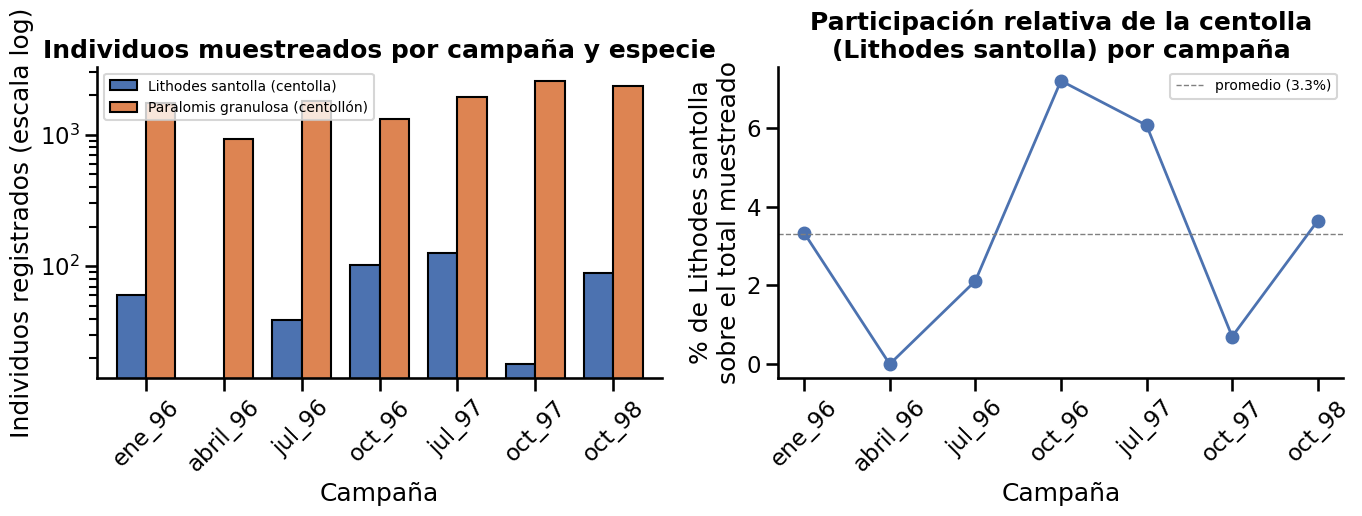

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

tab_especie.plot(kind='bar', ax=axes[0], color=['#4c72b0', '#dd8452'], edgecolor='black', width=0.75)
axes[0].set_yscale('log')
axes[0].set_ylabel('Individuos registrados (escala log)')
axes[0].set_xlabel('Campaña')
axes[0].set_title('Individuos muestreados por campaña y especie', fontweight='bold')
axes[0].legend(title='', fontsize=10)
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(orden_campanas, share_centolla.values, marker='o', color='#4c72b0', linewidth=2)
axes[1].set_ylabel('% de Lithodes santolla\nsobre el total muestreado')
axes[1].set_xlabel('Campaña')
axes[1].set_title('Participación relativa de la centolla\n(Lithodes santolla) por campaña', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].axhline(share_centolla.mean(), color='gray', linestyle='--', linewidth=1, label=f'promedio ({share_centolla.mean():.1f}%)')
axes[1].legend(fontsize=10)

sns.despine()
plt.tight_layout()
plt.show()

**Interpretación.** *Paralomis granulosa* (centollón) domina el muestreo en las 7 campañas por uno o dos órdenes de magnitud (nótese la escala logarítmica del panel izquierdo): esto confirma, con datos, la decisión (no explicitada en el TP2 original) de concentrar el resto del análisis en esa especie por volumen muestral. *Lithodes santolla* nunca desaparece del todo, pero su participación relativa es baja y oscila entre 0% (abril_96, sin ningún registro de centolla) y ~7% (oct_96), sin una tendencia claramente creciente o decreciente en el período 1996-1998: con solo 433 registros en total repartidos en 7 campañas, no alcanza para distinguir una tendencia real de ruido muestral. La recomendación práctica es que, si se quiere responder específicamente sobre el estado de la centolla (Lithodes santolla) y no solo del centollón, hace falta un muestreo dirigido a esa especie — este dataset no tiene la potencia estadística para eso.

## Pregunta 2 (TP1): ¿Cuándo se encontraron más huevos en las hembras?

**Planteo e implicancias.** Saber en qué campaña(s) hay más hembras con huevos permite recomendar una veda estacional que proteja el período reproductivo, cuando la especie es más vulnerable a la sobrepesca. Esta pregunta tiene una implicancia directa en el manejo pesquero: si se conoce la época de mayor actividad reproductiva, se puede prohibir la pesca (o exigir la devolución de hembras ovígeras) específicamente en esa ventana, en vez de aplicar una restricción uniforme todo el año.

**Desarrollo.** Se trabaja sobre hembras de *Paralomis granulosa* con dato válido de `huevos` (no se exige localización ni coordenadas, porque no hacen falta para esta pregunta — a diferencia del TP2 original, que sí exigía geolocalización completa antes de este punto). Se usa el mapeo de estados corregido en la sección de limpieza (los códigos 6 y 7 pasan a contar como "Con huevos", no como "Sin huevos"). Para que la corrección sea visible, se muestra también el resultado que se hubiese obtenido con el mapeo original de Mariano, campaña por campaña.

In [14]:
huevos_map_bug = {0: 'Sin huevos', 1: 'Con huevos', 2: 'Con huevos', 3: 'Con huevos',
                   4: 'Eclosionado', 5: 'Sin huevos', 6: 'Sin huevos', 7: 'Sin huevos'}
huevos_map_ok = {0: 'Sin huevos', 1: 'Con huevos', 2: 'Con huevos', 3: 'Con huevos',
                  4: 'Eclosionado/liberado', 5: 'Eclosionado/liberado',
                  6: 'Con huevos', 7: 'Con huevos'}

hembras = df_raw[(df_raw['especie'] == 2) & (df_raw['sexo'] == 2) & (df_raw['huevos'].notna())].copy()
print(f"N hembras de centollón con dato de huevos: {len(hembras):,}")

hembras['estado_bug'] = hembras['huevos'].map(huevos_map_bug)
hembras['estado_ok'] = hembras['huevos'].map(huevos_map_ok)

n_afectados = hembras['huevos'].isin([6, 7]).sum()
print(f"Registros con codigo 6 o 7 (mal etiquetados como 'Sin huevos' en el TP2 original): {n_afectados}")

N hembras de centollón con dato de huevos: 3,588
Registros con codigo 6 o 7 (mal etiquetados como 'Sin huevos' en el TP2 original): 219


In [15]:
tab_bug = pd.crosstab(hembras['fecha'], hembras['estado_bug'], normalize='index').mul(100).reindex(orden_campanas)
tab_ok = pd.crosstab(hembras['fecha'], hembras['estado_ok'], normalize='index').mul(100).reindex(orden_campanas)
n_por_campana = hembras.groupby('fecha', observed=False).size().reindex(orden_campanas)

comparacion = pd.DataFrame({
    '% con huevos (TP2 original, con el bug)': tab_bug.get('Con huevos'),
    '% con huevos (corregido)': tab_ok.get('Con huevos'),
    'N hembras': n_por_campana,
})
comparacion['diferencia (p.p.)'] = (comparacion['% con huevos (corregido)'] - comparacion['% con huevos (TP2 original, con el bug)']).round(1)
comparacion.round(1)

,"% con huevos (TP2 original, con el bug)",% con huevos (corregido),N hembras,diferencia (p.p.)
fecha,,,,
ene_96,71.1,77.6,558,6.5
abril_96,62.7,69.3,166,6.6
jul_96,40.2,42.2,453,2.0
oct_96,38.5,50.4,395,11.9
jul_97,73.7,76.9,632,3.2
oct_97,67.5,73.0,949,5.5
oct_98,63.2,73.3,435,10.1


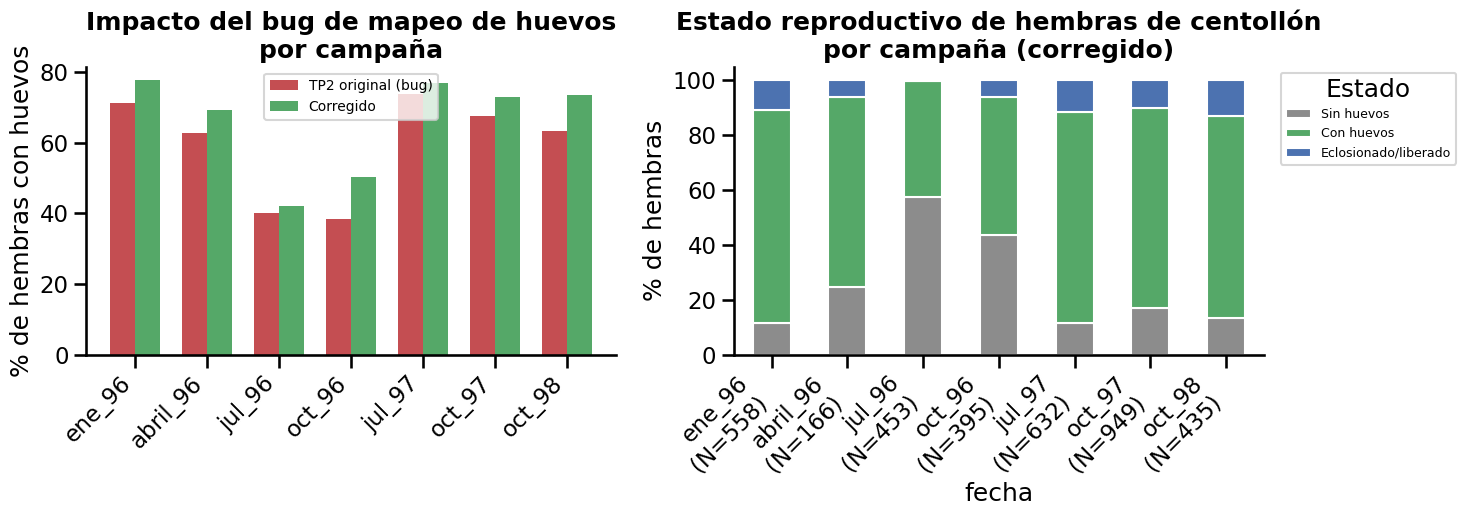

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

x = np.arange(len(orden_campanas))
width = 0.35
axes[0].bar(x - width/2, comparacion['% con huevos (TP2 original, con el bug)'], width, label='TP2 original (bug)', color='#c44e52')
axes[0].bar(x + width/2, comparacion['% con huevos (corregido)'], width, label='Corregido', color='#55a868')
axes[0].set_xticks(x)
axes[0].set_xticklabels(orden_campanas, rotation=45, ha='right')
axes[0].set_ylabel('% de hembras con huevos')
axes[0].set_title('Impacto del bug de mapeo de huevos\npor campaña', fontweight='bold')
axes[0].legend(fontsize=10)

tab_ok_plot = tab_ok.reindex(columns=['Sin huevos', 'Con huevos', 'Eclosionado/liberado']).fillna(0)
tab_ok_plot.plot(kind='bar', stacked=True, ax=axes[1], color=['#8c8c8c', '#55a868', '#4c72b0'], edgecolor='white')
etiquetas = [f"{t}\n(N={int(n_por_campana[t])})" for t in orden_campanas]
axes[1].set_xticklabels(etiquetas, rotation=45, ha='right')
axes[1].set_ylabel('% de hembras')
axes[1].set_title('Estado reproductivo de hembras de centollón\npor campaña (corregido)', fontweight='bold')
axes[1].legend(title='Estado', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)

sns.despine()
plt.tight_layout()
plt.show()

**Interpretación.** La corrección del mapeo cambia el porcentaje de hembras "con huevos" en todas las campañas, con diferencias de entre 2.0 y 11.9 puntos porcentuales (las más afectadas: oct_96 y oct_98). Con los datos corregidos, las campañas de **enero, julio (ambos años) y octubre_97** muestran la mayor proporción de hembras ovígeras (>60-70%), mientras que **julio_96 y octubre_96** muestran los valores más bajos (~40-50%). Esto es coherente con un patrón reproductivo estacional marcado más que aleatorio. La implicancia de manejo es concreta: si se va a recomendar una veda reproductiva, las campañas de enero/julio/octubre-97 son las candidatas naturales por concentrar la mayor proporción de hembras ovígeras — y el bug del TP2 original, al subestimar sistemáticamente esa proporción, hubiese debilitado artificialmente ese argumento.

## Pregunta 3 (TP1): ¿Dónde se pescaron mayor cantidad de hembras con huevos en estos períodos?

**Planteo e implicancias.** Además de restringir la pesca en el tiempo (pregunta 2), se puede restringir en el espacio: si ciertas localizaciones concentran una proporción mucho mayor de hembras ovígeras que otras, esas zonas son candidatas a una veda espacial (o a una recomendación de liberar hembras ovígeras específicamente ahí), sin necesidad de cerrar toda la pesquería.

**Desarrollo.** A diferencia del TP2 original (que exigía `latitud`, `longitud` y `localizacion` simultáneamente, perdiendo ~108 registros con coordenadas válidas pero sin nombre de localización), acá solo se exige que la fila tenga coordenadas — es lo único que hace falta para ubicarla en el mapa. Se agrupa por `localizacion_norm`, se calcula la tasa de hembras con huevos (usando el mapeo corregido de la pregunta 2) y se exige un mínimo de 5 hembras por localización para no graficar tasas basadas en 1 o 2 casos.

In [17]:
req_localizacion = df_raw[(df_raw['especie']==2)&(df_raw['sexo']==2)].dropna(subset=['latitud','longitud','localizacion'], how='any')
req_solo_coords = df_raw[(df_raw['especie']==2)&(df_raw['sexo']==2)].dropna(subset=['latitud','longitud'], how='any')
print(f"Filas si se exige tambien 'localizacion' (criterio del TP2 original): {len(req_localizacion):,}")
print(f"Filas exigiendo solo lat/lon (este notebook): {len(req_solo_coords):,}  (+{len(req_solo_coords)-len(req_localizacion)} registros recuperados)")

hembras_geo = req_solo_coords[req_solo_coords['huevos'].notna()].copy()
hembras_geo['con_huevos'] = hembras_geo['huevos'].map(huevos_map_ok) == 'Con huevos'

agg_loc = hembras_geo.groupby('localizacion_norm').agg(
    lat=('latitud', 'median'),
    lon=('longitud', 'median'),
    n_hembras=('con_huevos', 'size'),
    n_con_huevos=('con_huevos', 'sum'),
).reset_index()
agg_loc = agg_loc[agg_loc['n_hembras'] >= 5].copy()
agg_loc['tasa_con_huevos_%'] = (agg_loc['n_con_huevos'] / agg_loc['n_hembras'] * 100).round(1)
agg_loc = agg_loc.sort_values('tasa_con_huevos_%', ascending=False).reset_index(drop=True)

print(f"\nLocalizaciones con al menos 5 hembras muestreadas: {len(agg_loc)}")
agg_loc

Filas si se exige tambien 'localizacion' (criterio del TP2 original): 2,748
Filas exigiendo solo lat/lon (este notebook): 2,793  (+45 registros recuperados)

Localizaciones con al menos 5 hembras muestreadas: 43


,localizacion_norm,lat,lon,n_hembras,n_con_huevos,tasa_con_huevos_%
0,wp 61,-54.901683,-67.195083,5,5,100.0
1,wp 154,-54.864983,-67.877283,136,127,93.4
2,wp 241,-54.886967,-67.711850,38,35,92.1
3,wp 150,-54.858083,-68.039783,34,31,91.2
4,wp 242,-54.889667,-67.696800,41,37,90.2
5,wp 236,-54.886100,-67.602967,116,103,88.8
6,wp 172,-54.929283,-67.064200,199,176,88.4
7,al s de baliza de e. remolino,-54.869617,-67.860617,117,99,84.6
8,wp 165,-54.908433,-67.196817,93,77,82.8
9,wp 151,-54.856433,-68.035083,44,36,81.8


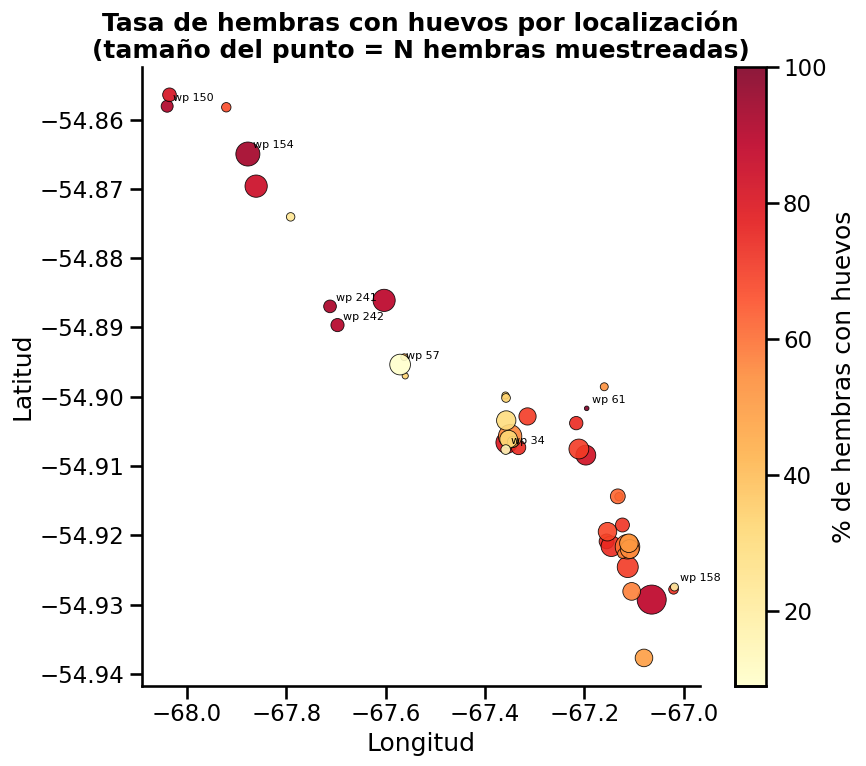

In [18]:
fig, ax = plt.subplots(figsize=(9, 8))
sc = ax.scatter(agg_loc['lon'], agg_loc['lat'], s=agg_loc['n_hembras']*2.2,
                 c=agg_loc['tasa_con_huevos_%'], cmap='YlOrRd', edgecolor='black', linewidth=0.6, alpha=0.9)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('% de hembras con huevos')

top5 = agg_loc.head(5)
bottom3 = agg_loc.tail(3)
for _, r in pd.concat([top5, bottom3]).iterrows():
    ax.annotate(r['localizacion_norm'], (r['lon'], r['lat']), fontsize=8,
                xytext=(4, 4), textcoords='offset points')

ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
ax.set_title('Tasa de hembras con huevos por localización\n(tamaño del punto = N hembras muestreadas)', fontweight='bold')
sns.despine()
plt.tight_layout()
plt.show()

**Interpretación.** La tasa de hembras con huevos varía fuertemente según la localización: desde ~9% (wp 57) hasta 100% (wp 61, aunque con solo 5 casos) o >88% en localizaciones con buen volumen muestral (wp 154, wp 236, wp 172, todas con más de 100 hembras). Las localizaciones etiquetadas como `wp 1xx`-`wp 2xx` en general muestran tasas más altas que `wp 30`-`wp 35` y `wp 57`/`wp 58`, lo que sugiere una diferencia espacial real (no solo ruido muestral, dado el N de cada grupo) entre zonas de cría/reproducción y zonas de alimentación o paso. Estas localizaciones de alta tasa (`wp 154`, `wp 236`, `wp 241`, `wp 242`, `wp 172`) son las candidatas más claras a una restricción espacial de pesca durante la temporada reproductiva.

## Síntesis: ¿dónde y cuándo no pescar? (pregunta 5 del TP1)

*(Esta sección no cuenta para el mínimo de 3 preguntas exigido por la consigna — ya cumplido con las preguntas 1, 2 y 3 — pero conecta los resultados anteriores con el objetivo final del proyecto.)*

Combinando las preguntas 2 y 3: las campañas de **enero, julio (ambos años) y octubre_97** concentran la mayor proporción de hembras de centollón con huevos, y dentro de esas campañas las localizaciones **wp 154, wp 236, wp 241, wp 242 y wp 172** muestran las tasas más altas de hembras ovígeras con volumen muestral suficiente. Una recomendación de manejo basada en estos datos sería restringir la pesca (o exigir liberación de hembras) específicamente en esas localizaciones durante esas campañas, en lugar de aplicar una veda general todo el año en toda el área. Para *Lithodes santolla* (pregunta 1), el volumen de datos disponible (433 registros) no alcanza para una recomendación espacial o temporal propia con la misma confianza.

## Cierre de los TO-DO que quedaron pendientes en `mariano_tp2.ipynb`

El TP2 original terminaba con una lista de 4 tareas sin resolver y una celda final vacía. Los cierro acá:

1. *Graficar la longitud y la latitud en un mapa* → ya resuelto en el mapa de la pregunta 3.
2. *Imputar la profundidad usando de referencia latitud y longitud.*
3. *Mostrar EDA del caparazón.*
4. *Gráfica temporal mostrando cantidad de trampas muestreadas por expedición* — nota: el TP2 original grafica la cantidad de **individuos** registrados por campaña bajo el título "volumen de pesca", pero eso mide la captura, no el esfuerzo. Acá se muestran ambas métricas por separado para no confundirlas.

In [19]:
# TODO 2: imputar profundidad con los 5 vecinos mas cercanos en lat/lon
falt_antes = df_raw['profundidad'].isna().sum()

con_coords = df_raw.dropna(subset=['latitud', 'longitud'])
train = con_coords[con_coords['profundidad'].notna()]
falta = df_raw[df_raw['profundidad'].isna() & df_raw['latitud'].notna() & df_raw['longitud'].notna()]

if len(train) > 0 and len(falta) > 0:
    nn = NearestNeighbors(n_neighbors=5).fit(train[['latitud', 'longitud']])
    _, idx = nn.kneighbors(falta[['latitud', 'longitud']])
    df_raw.loc[falta.index, 'profundidad'] = train['profundidad'].values[idx].mean(axis=1)

falt_despues = df_raw['profundidad'].isna().sum()
print(f"Faltantes de 'profundidad' antes: {falt_antes} | despues de imputar por 5 vecinos mas cercanos (lat/lon): {falt_despues}")
print("(quedan sin imputar los registros que tampoco tienen coordenadas: no hay de donde tomar una referencia espacial)")

Faltantes de 'profundidad' antes: 3346 | despues de imputar por 5 vecinos mas cercanos (lat/lon): 3233
(quedan sin imputar los registros que tampoco tienen coordenadas: no hay de donde tomar una referencia espacial)


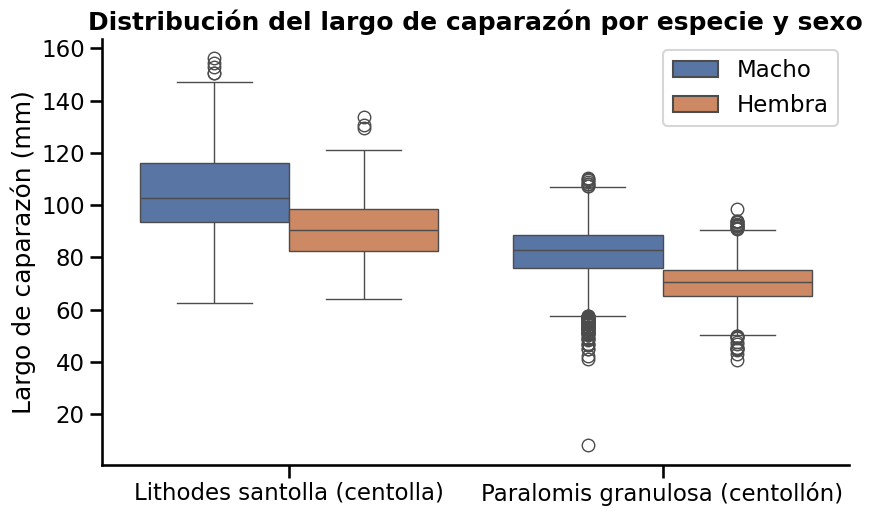

count   mean   std   min    50%  \
especie_nombre                  sexo_nombre                                     
Lithodes santolla (centolla)    Hembra        160.0   91.7  12.7  64.2   90.6   
                                Macho         273.0  105.3  18.8  62.6  102.9   
Paralomis granulosa (centollón) Hembra       3666.0   70.3   7.5  40.9   70.5   
                                Macho        8984.0   82.1   9.3   8.1   82.8   

                                               max  
especie_nombre                  sexo_nombre         
Lithodes santolla (centolla)    Hembra       133.8  
                                Macho        156.2  
Paralomis granulosa (centollón) Hembra        98.4  
                                Macho        110.2

In [20]:
# TODO 3: EDA de largo_caparazon por especie y sexo
fig, ax = plt.subplots(figsize=(9, 5.5))
orden_box = ['Lithodes santolla (centolla)', 'Paralomis granulosa (centollón)']
sns.boxplot(data=df_raw, x='especie_nombre', y='largo_caparazon', hue='sexo_nombre',
            order=orden_box, palette=['#4c72b0', '#dd8452'], ax=ax)
ax.set_xlabel('')
ax.set_ylabel('Largo de caparazón (mm)')
ax.set_title('Distribución del largo de caparazón por especie y sexo', fontweight='bold')
ax.legend(title='')
sns.despine()
plt.tight_layout()
plt.show()

df_raw.groupby(['especie_nombre', 'sexo_nombre'], observed=False)['largo_caparazon'].describe()[['count','mean','std','min','50%','max']].round(1)

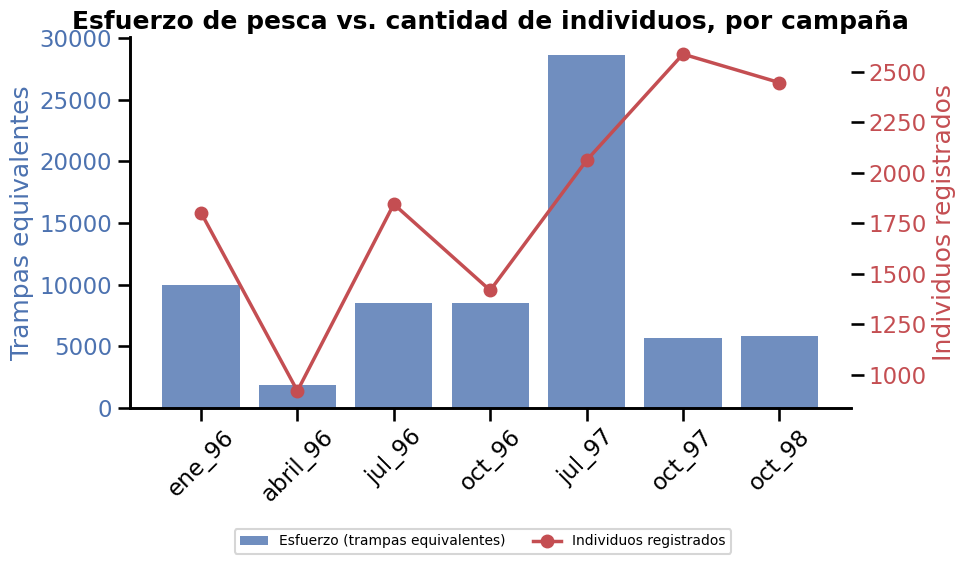

In [21]:
# TODO 4: esfuerzo de pesca (trampas equivalentes) vs cantidad de individuos, por campana
esfuerzo = df_raw.dropna(subset=['num_trampas']).groupby('fecha', observed=False)['num_trampas'].sum().reindex(orden_campanas)
individuos = df_raw.groupby('fecha', observed=False).size().reindex(orden_campanas)

fig, ax1 = plt.subplots(figsize=(10, 5.5))
ax1.bar(orden_campanas, esfuerzo.values, color='#4c72b0', alpha=0.8, label='Esfuerzo (trampas equivalentes)')
ax1.set_ylabel('Trampas equivalentes', color='#4c72b0')
ax1.tick_params(axis='y', labelcolor='#4c72b0')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.plot(orden_campanas, individuos.values, color='#c44e52', marker='o', linewidth=2.5, label='Individuos registrados')
ax2.set_ylabel('Individuos registrados', color='#c44e52')
ax2.tick_params(axis='y', labelcolor='#c44e52')

ax1.set_title('Esfuerzo de pesca vs. cantidad de individuos, por campaña', fontweight='bold')
fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0.02), ncol=2, fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()

**Interpretación de los TODOs cerrados.** El caparazón de *Lithodes santolla* es sistemáticamente más grande que el de *Paralomis granulosa* en ambos sexos (medianas ~91-103mm vs ~70-83mm), y en las dos especies los machos superan a las hembras en tamaño — consistente con lo esperado biológicamente para lithódidos. En el gráfico de esfuerzo vs. captura, **julio_97** combina el mayor esfuerzo de pesca (más trampas equivalentes) con una captura moderada, mientras que **octubre_97 y octubre_98** logran más individuos registrados con menos esfuerzo relativo — es decir, mayor eficiencia de captura (más individuos por trampa), lo cual es coherente con ser también las campañas de mayor actividad reproductiva encontradas en la pregunta 2.

## Conclusiones y limitaciones

- Las preguntas 1, 2 y 3 del TP1 quedaron respondidas con el planteo, desarrollo, gráfico e interpretación pedidos por la consigna, y la síntesis final conecta los resultados con la pregunta 5 (dónde y cuándo no pescar).
- Se corrigió un error real de mapeo de estado de huevos que subestimaba la proporción de hembras ovígeras entre 2 y 12 puntos porcentuales según la campaña, y se robusteció la limpieza de `huevos`/`cirripedio` para no depender de enumerar a mano cada variante de texto libre.
- **Limitación de tamaño muestral:** cualquier conclusión sobre *Lithodes santolla* (centolla) es débil por tener solo 433 registros; este dataset está mejor preparado para conclusiones sobre *Paralomis granulosa* (centollón).
- **Limitación temporal:** los datos van de 1996 a 1998. Cualquier recomendación de manejo pesquero basada en este análisis debería contrastarse con datos más recientes antes de aplicarse.
- **Punto abierto:** el TP2 original filtra individuos con `largo_caparazon >= 60,6mm` sin citar la fuente de ese umbral (probablemente una talla mínima legal de la pesquería). No lo reutilizo sin poder verificar la cita exacta; si se confirma la normativa correspondiente, aplicar ese filtro a las preguntas 2 y 3 sería un buen próximo paso para responder específicamente sobre la fracción de la población legalmente capturable.